In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import anndata as ad
import yaml

adata = ad.read_h5ad("../data_interim/tissuexcell.h5ad")

In [ ]:
params = {
    "input": "../data_interim/tissuexcell.h5ad",
    "data": {"n_cells": int(adata.n_obs),"n_genes": int(adata.n_vars),},
    "pca": {"n_hvg": 3000,"n_components": 50,"hvg_flavor": "seurat","svd_solver": "arpack"},
    "sample_level_pca": {"groupby": ["mouse.id","tissue","major_cell_type"],"aggregation": "mean"},
    "age_group": {"source": "age_months","method": "predefined_age_stages","groups": {"young": [1, 3],"middle": [18, 21],"old": [24, 30]}},
    "output": {"sample_level_pca": "../results/pca/mouse_level_pca.csv"}
}

os.makedirs("../config", exist_ok=True)

with open("../config/analysis_parameters_v1.yaml","w",encoding="utf-8") as f:
    yaml.dump(params,f,allow_unicode=True,sort_keys=False)

In [3]:
adata.X = adata.layers["log1p_norm"].copy()

In [4]:
sc.pp.highly_variable_genes(adata,n_top_genes=3000,flavor="seurat")

C:\Users\asd123cheese\AppData\Local\Temp\ipykernel_36372\1859157049.py:1: UserWarning: `n_top_genes` (=3000) > number of normalized dispersions (=2962), returning all genes with normalized dispersions.
  sc.pp.highly_variable_genes(adata,n_top_genes=3000,flavor="seurat")


In [5]:
sc.pp.pca(adata,n_comps=50,mask_var="highly_variable",svd_solver="arpack")

In [6]:
sc.pp.neighbors(adata,n_neighbors=30,n_pcs=50)
sc.tl.umap(adata)

c:\Users\asd123cheese\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


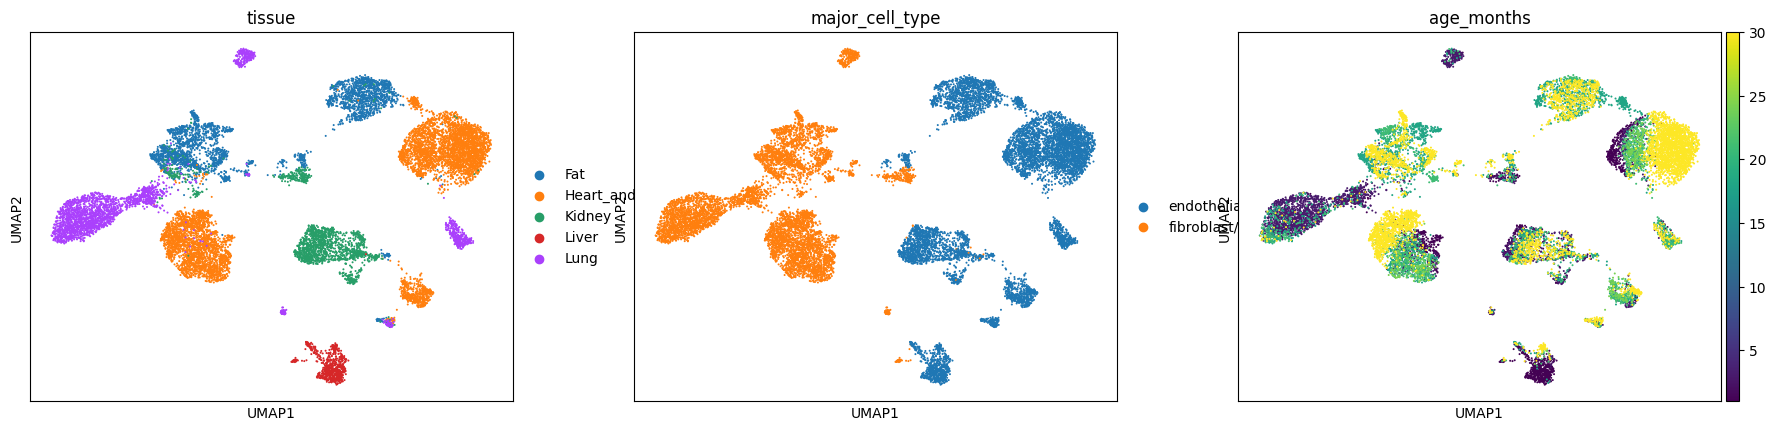

In [7]:
sc.pl.umap(adata,color=["tissue","major_cell_type","age_months"])

In [11]:
pca_df = pd.DataFrame(adata.obsm["X_pca"][:, :50],index=adata.obs_names)

pca_df.columns = [f"PC{i}"for i in range(1,51)]

In [12]:
pca_df = pd.concat([pca_df,adata.obs[["mouse.id","tissue","major_cell_type","age_months"]]],axis=1)

In [13]:
mouse_level_pca = (pca_df.groupby(["mouse.id","tissue","major_cell_type","age_months"]).mean().reset_index())

C:\Users\asd123cheese\AppData\Local\Temp\ipykernel_36372\2642009933.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mouse_level_pca = (pca_df.groupby(["mouse.id","tissue","major_cell_type","age_months"]).mean().reset_index())


In [14]:
# 确定年龄分组
def assign_age_group(age):
    if age in [1, 3]:
        return "young"
    elif age in [18, 21]:
        return "middle"
    elif age in [24, 30]:
        return "old"
    else:
        return np.nan

mouse_level_pca["age_group"] = (mouse_level_pca["age_months"].apply(assign_age_group))

In [ ]:
print(mouse_level_pca[["mouse.id", "tissue", "major_cell_type","age_months", "age_group"]].head())

  mouse.id tissue major_cell_type  age_months age_group
0   1-M-62    Fat     endothelial         1.0     young
1   1-M-62    Fat     endothelial         3.0     young
2   1-M-62    Fat     endothelial        18.0    middle
3   1-M-62    Fat     endothelial        21.0    middle
4   1-M-62    Fat     endothelial        24.0       old


In [ ]:
print(mouse_level_pca["age_group"].value_counts())

age_group
young     420
middle    420
old       420
Name: count, dtype: int64


In [ ]:
print(pd.crosstab(mouse_level_pca["tissue"],mouse_level_pca["age_group"]))

age_group        middle  old  young
tissue                             
Fat                  84   84     84
Heart_and_Aorta      84   84     84
Kidney               84   84     84
Liver                84   84     84
Lung                 84   84     84


In [20]:
os.makedirs("../results/pca",exist_ok=True)

mouse_level_pca.to_csv("../results/pca/mouse_level_pca.csv",index=False)

In [21]:
adata.write_h5ad("../data_processed/main_qc_pca.h5ad",compression="gzip")